# 使用Scikit-Learn 完成預測
### Scikit-Learn在三個面向提供支援。
1. 獲取資料:***klearn.datasets***
2. 掌握資料:***sklearn.preprocessing*** 
3. 機器學習:***sklearn Estimator API*** 

獲取資料的方式有很多種（包含檔案、資料庫、網路爬蟲、Kaggle Datasets等），<br>
其中最簡單的方式是從Sklearn import 內建的資料庫。由於其特性隨手可得且不用下載，所以我們通常叫他**玩具資料**：

# 基本架構

* 讀取資料&pre-processing
* 切分訓練集與測試集 
* 模型配適
* 預測 
* 評估(計算成績可能是誤差值或正確率或..)


In [129]:
%matplotlib inline

from sklearn import datasets
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## 讀取Iris資料集與資料前處理

Iris Flowers 資料集

我們在這個項目中使用 Iris Data Set，這個資料集中的每個樣本有4個特徵，1個類別。該資料集1中的樣本類別數為3類，每類樣本數目為50個，總共150個樣本。

屬性資訊：

    花萼長度 sepal length(cm)
    花萼寬度 sepal width(cm)
    花瓣長度 petal length(cm)
    花瓣寬度 petal width(cm)
    類別：
        Iris Setosa
        Iris Versicolour
        Iris Virginica

樣本特徵資料是數值型的，而且單位都相同（釐米）。

![Iris Flowers](images/iris_data.PNG)


In [130]:
iris = datasets.load_iris()
print(iris.DESCR)

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

* 印出iris的key值與檔案位置
* 查看前10筆資料
* 查看資料型別
* 印出標註的樣本類別資料

In [131]:
print(iris.keys())
print(iris['filename'])
print(iris.data[0:10])
print(iris.target_names)
print(iris.target)

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])
iris.csv
[[5.1 3.5 1.4 0.2]
 [4.9 3.  1.4 0.2]
 [4.7 3.2 1.3 0.2]
 [4.6 3.1 1.5 0.2]
 [5.  3.6 1.4 0.2]
 [5.4 3.9 1.7 0.4]
 [4.6 3.4 1.4 0.3]
 [5.  3.4 1.5 0.2]
 [4.4 2.9 1.4 0.2]
 [4.9 3.1 1.5 0.1]]
['setosa' 'versicolor' 'virginica']
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 2 2 2 2 2 2 2 2 2 2 2
 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2 2
 2 2]


In [132]:
X=iris.data[:,:2]

print(X.shape)# we only take the first two features. 
Y=iris.target
print(Y.shape)# we only take the first two features. 


(150, 2)
(150,)


In [133]:
#以下是組成 pandas DataFrame (也可以不用這種做)
#x = pd.DataFrame(iris.data, columns=iris['feature_names'])
x = pd.DataFrame(iris.data, columns=iris['feature_names'])
x.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
5,5.4,3.9,1.7,0.4
6,4.6,3.4,1.4,0.3
7,5.0,3.4,1.5,0.2
8,4.4,2.9,1.4,0.2
9,4.9,3.1,1.5,0.1


In [134]:
print("target_name:"+str(iris['target_names']))

target_name:['setosa' 'versicolor' 'virginica']


In [135]:
y=pd.DataFrame(iris['target'],columns=['target'])
y.head(150)

,target
0,0
1,0
2,0
3,0
4,0
...,...
145,2
146,2
147,2
148,2


In [136]:
#合併資料特徵欄位與目標欄位
iris.data=pd.concat([x,y],axis=1)
iris.data.head(10)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0
5,5.4,3.9,1.7,0.4,0
6,4.6,3.4,1.4,0.3,0
7,5.0,3.4,1.5,0.2,0
8,4.4,2.9,1.4,0.2,0
9,4.9,3.1,1.5,0.1,0


In [137]:
#只選擇目標為0與1的資料
#iris_data=iris.data[['sepal length (cm)','sepal width (cm)','target']]
iris_data=iris.data[['sepal length (cm)','petal length (cm)','target']]
iris_data.head(10)#資料視覺化

iris_data=iris_data[iris_data['target'].isin([0,1])]
iris_data
print(iris_data.shape)
iris_data


(100, 3)


,sepal length (cm),petal length (cm),target
0,5.1,1.4,0
1,4.9,1.4,0
2,4.7,1.3,0
3,4.6,1.5,0
4,5.0,1.4,0
...,...,...,...
95,5.7,4.2,1
96,5.7,4.2,1
97,6.2,4.3,1
98,5.1,3.0,1


## 切分訓練集與測試集
> train_test_split()

In [138]:
from sklearn.model_selection import train_test_split
#X_train,X_test,Y_train,Y_test=train_test_split(iris_data[['sepal length (cm)','sepal width (cm)']],iris_data['target'],test_size=0.3,random_state=0)
X_train,X_test,Y_train,Y_test=train_test_split(iris_data[['sepal length (cm)','petal length (cm)']],iris_data['target'],test_size=0.3,random_state=0)


In [139]:
X_train.head()

,sepal length (cm),petal length (cm)
60,5.0,3.5
80,5.5,3.8
90,5.5,4.4
68,6.2,4.5
51,6.4,4.5


In [140]:
X_test.head()
Y_train.head()


60    1
80    1
90    1
68    1
51    1
Name: target, dtype: int64

# Appendix 

>normalization和standardization是差不多的<br>
都是把數據進行前處理，從而使數值都落入到統一的數值範圍，從而在建模過程中，各個特徵量沒差別對待。<br> 
* normalization一般是把數據限定在需要的範圍，比如一般都是【0，1】，從而消除了數據量綱對建模的影響。<br> 
* standardization 一般是指將數據正態化，使平均值0方差為1.<br> 

因此normalization和standardization 是針對數據而言的，消除一些數值差異帶來的特種重要性偏見。<br>
經過歸一化的數據，能加快訓練速度，促進算法的收斂。

### Standardization (z-score)
    to compute the mean and standard deviation on a training set so as to be able to later reapply the same transformation on the testing set. 

In [141]:
#df = pd.DataFrame()
#print(df)

def norm_stats(dfs):
    minimum = dfs.min()
    #print("minimum=",minimum)
    #print("end minimum")
    maximum = dfs.max()
    mu = dfs.mean()
    sigma = dfs.std()
    return (minimum, maximum, mu, sigma)


def z_score(col, stats):
    m, M, mu, s = stats
    df = pd.DataFrame()
    for c in col.columns:
        df[c] = (col[c]-mu[c])/s[c]
        #print(col[c])
        #print(mu[c])
        #print(s[c])
        #print(df[c])
    return df


In [156]:
#print("X_train'",X_train)
stats = norm_stats(X_train)
#print("stats=",stats)
#print("end stats=")
arr_x_train = np.array(z_score(X_train, stats))
arr_y_train = np.array(Y_train)
arr_x_train[:5]
#arr_x_train.shape
#arr_x_train[3,:]

array([[-0.8022155 ,  0.43353572],
       [ 0.01637174,  0.6399813 ],
       [ 0.01637174,  1.05287246],
       [ 1.16239388,  1.12168766],
       [ 1.48982878,  1.12168766]])

## use sklearn

In [143]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler().fit(X_train)  #Compute the statistics to be used for later scaling.
print(sc.mean_)  #mean
print(sc.scale_) #standard deviation

[5.49 2.87]
[0.60642983 1.44275035]


In [144]:
#transform: (x-u)/std.
X_train_std = sc.transform(X_train)
X_train_std[:5]

array([[-0.80800774,  0.43666598],
       [ 0.01648995,  0.64460217],
       [ 0.01648995,  1.06047453],
       [ 1.17078673,  1.12978659],
       [ 1.50058581,  1.12978659]])

The scaler instance can then be used on new data to transform it the same way it did on the training set:

In [145]:
X_test_std = sc.transform(X_test)
print(X_test_std[:10])

[[-0.80800774 -0.88026317]
 [ 1.99528442  1.26841071]
 [-1.30270636 -1.08819936]
 [ 0.34628903  1.12978659]
 [ 1.83038488  1.06047453]
 [-0.80800774  0.29804186]
 [-0.14840959 -1.08819936]
 [ 1.00588719  1.26841071]
 [ 1.66548534  1.19909865]
 [ 0.34628903  0.92185041]]


you can also use fit_transform method (i.e., fit and then transform)    

In [157]:
X_train_std = sc.fit_transform(X_train)  
X_test_std = sc.fit_transform(X_test)
print(X_test_std[:10])


[[-0.6046352  -0.86053032]
 [ 1.80445816  1.29079547]
 [-1.02976932 -1.06872313]
 [ 0.38734442  1.15200026]
 [ 1.66274679  1.08260266]
 [-0.6046352   0.31922899]
 [-0.0377897  -1.06872313]
 [ 0.95418992  1.29079547]
 [ 1.52103541  1.22139787]
 [ 0.38734442  0.94380744]]


In [147]:
print('mean of X_train_std:',np.round(X_train_std.mean(),4))
print('std of X_train_std:',X_train_std.std())

mean of X_train_std: -0.0
std of X_train_std: 0.9999999999999999


## Min-Max Normaliaztion
    Transforms features by scaling each feature to a given range.
    The transformation is given by:

    X' = X - X.min(axis=0) / ((X.max(axis=0) - X.min(axis=0))
    X -> N 維資料
    


50.35199871946029
29.921024104075478


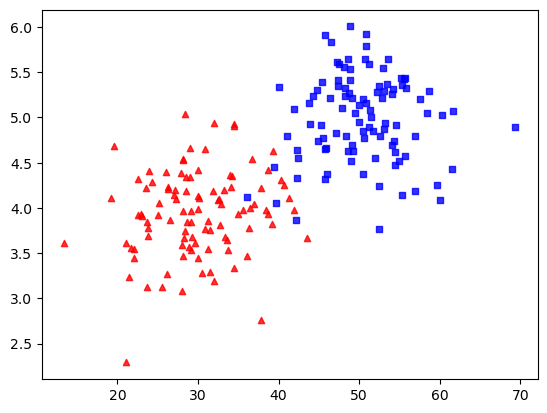

In [148]:
x1 = np.random.normal(50, 6, 100)  # np.random.normal(mu,sigma,size))
y1 = np.random.normal(5, 0.5, 100)

x2 = np.random.normal(30,6,100)
y2 = np.random.normal(4,0.5,100)
plt.scatter(x1,y1,c='b',marker='s',s=20,alpha=0.8)
plt.scatter(x2,y2,c='r', marker='^', s=20, alpha=0.8)

print(np.sum(x1)/len(x1))
print(np.sum(x2)/len(x2))

In [149]:
x_val = np.concatenate((x1,x2))
y_val = np.concatenate((y1,y2))

x_val.shape

(200,)

In [150]:
def minmax_norm(X):
    return (X - X.min(axis=0)) / ((X.max(axis=0) - X.min(axis=0)))

In [151]:
minmax_norm(x_val[:10])

array([0.83705053, 0.59141294, 0.4486178 , 0.35145423, 0.        ,
       1.        , 0.73590868, 0.64659473, 0.8770511 , 0.18767568])

In [159]:
from sklearn.preprocessing import MinMaxScaler
x_val=x_val.reshape(-1, 1)
scaler = MinMaxScaler().fit(x_val)  # default range 0~1
print(scaler.data_max_)
print(scaler.data_min_)
print(scaler.transform(x_val)[:10])

[69.37181465]
[13.41645133]
[[0.69712029]
 [0.62865709]
 [0.58885776]
 [0.56177669]
 [0.46382066]
 [0.74253697]
 [0.66893041]
 [0.64403716]
 [0.70826911]
 [0.51612893]]
